# 1. [맷플롯립] 2017년 지역별 미세먼지 세로 막대 그래프

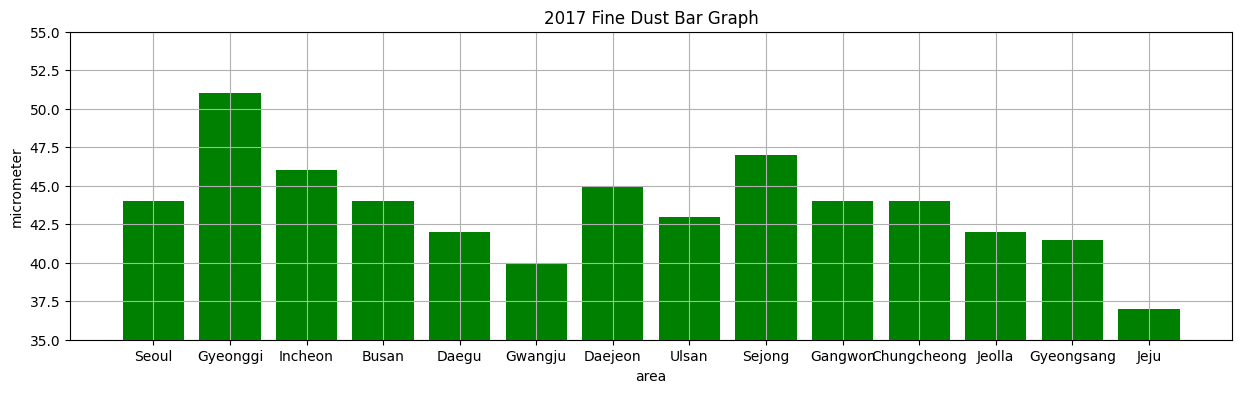

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('fine_dust.xlsx', index_col='area')
data2017 = data[2017]

plt.figure(figsize=(15, 4))
plt.bar(data2017.index, data2017, color='g')
plt.ylim(35, 55)
plt.xlabel('area')
plt.ylabel('micrometer')
plt.title('2017 Fine Dust Bar Graph')
plt.grid()
plt.show()

# 2. [맷플롯립] 키, 몸무게 산점도 그래프

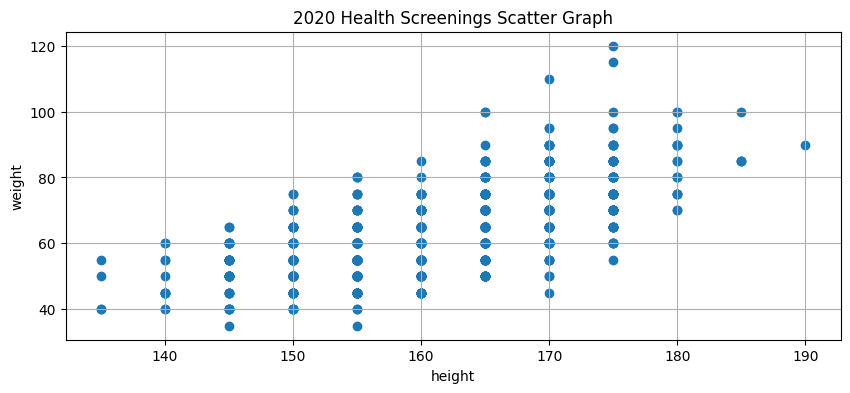

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
heightdata = data['height']
weightdata = data['weight']

plt.figure(figsize=(10,4))
plt.scatter(heightdata, weightdata)
plt.xlabel('height')
plt.ylabel('weight')
plt.title('2020 Health Screenings Scatter Graph')
plt.grid()
plt.show()

In [12]:
# 3 ~ 9 공통 사용 데이터
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')

data6 = data.loc[:, ['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]
data6['gender'] = data6['gender'].replace({1: 'Male', 2: 'Female'})
data6['drinking'] = data6['drinking'].replace({0: 'Non-drinking', 1: 'Drinking'})
data6['smoking'] = data['smoking'].replace({1: 'Non-smoking', 2:'Non-smoking', 3:'Smoking'})

male_data = data6.loc[data6.gender == 'Male', ['gender', 'weight', 'waist', 'drinking' ,'smoking']]
female_data = data6.loc[data6.gender == 'Female', ['gender', 'weight' , 'waist', 'drinking', 'smoking']]

# 3. [시본] 성별 음주,흡연 상태 시본 막대 그래프 - 서브 플롯

Text(0.5, 1.0, 'Smoking Type')

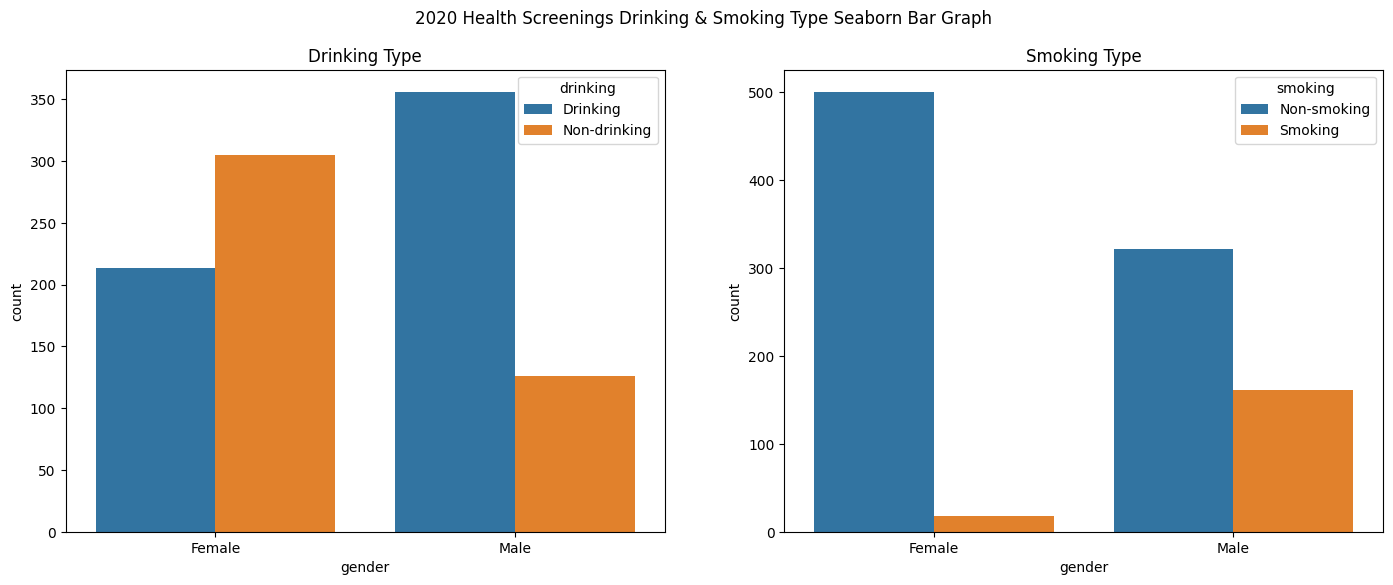

In [21]:
drinking = data6.groupby(['gender', 'drinking']).size().reset_index(name='count')
smoking = data6.groupby(['gender', 'smoking']).size().reset_index(name='count')

fig = plt.figure(figsize=(17,6))

area1 = fig.add_subplot(1, 2, 1)
area2 = fig.add_subplot(1, 2, 2)

ax1 = sns.barplot(data=drinking, x='gender', y='count', hue='drinking', ax=area1)
ax2 = sns.barplot(data=smoking, x='gender', y='count', hue='smoking', ax=area2)

fig.suptitle('2020 Health Screenings Drinking & Smoking Type Seaborn Bar Graph')
area1.set_title('Drinking Type')
area2.set_title('Smoking Type')

# 4.[시본] 남녀 허리둘레, 몸무게 스트립 플롯 그래프

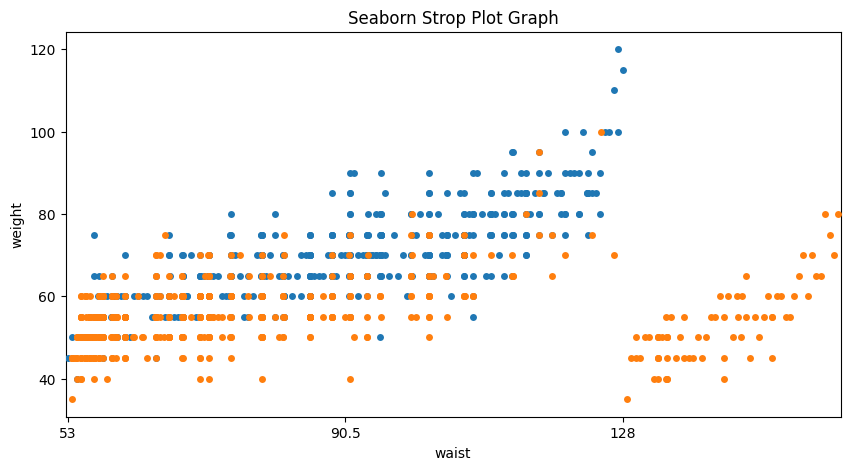

In [24]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strop Plot Graph')

sns.stripplot(data=male_data, x='waist', y='weight')
sns.stripplot(data=female_data, x='waist', y='weight')

plt.xticks(np.arange(0,127,63), labels=[53,90.5,128])
plt.show()

# 5. [시본] 음주 여부별 허리둘레 분퍼 - 패싯 그리드 그래프

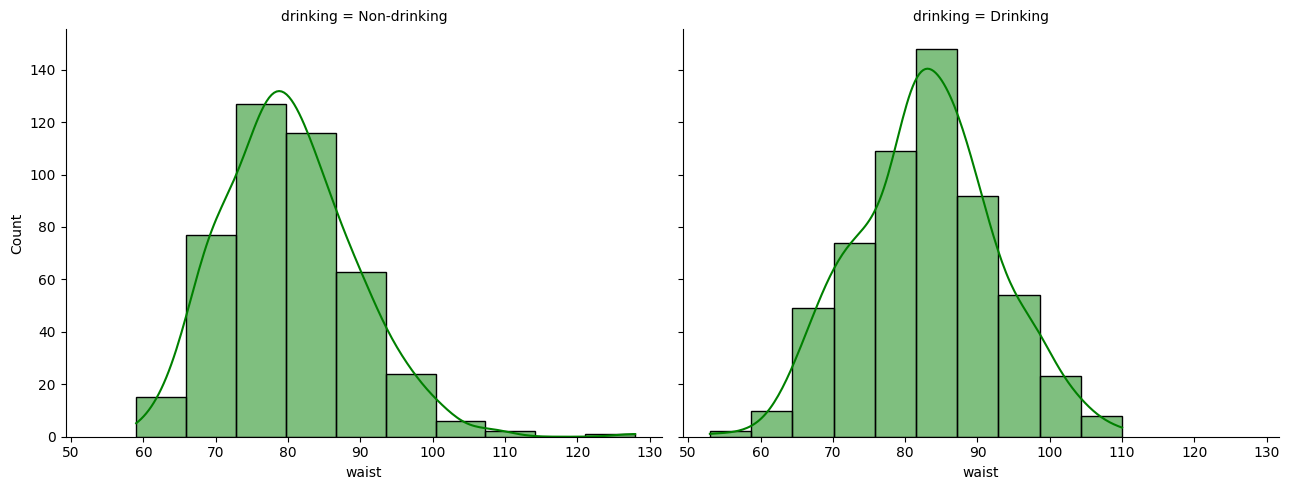

In [ ]:
fg = sns.FacetGrid(data6, col='drinking', height=5, aspect=1.3)
fg.map(sns.histplot, 'waist', bins=10, color='g', kde=True)

plt.show()

# 6. [시본] 남녀 몸무게 히스토그램 그래프

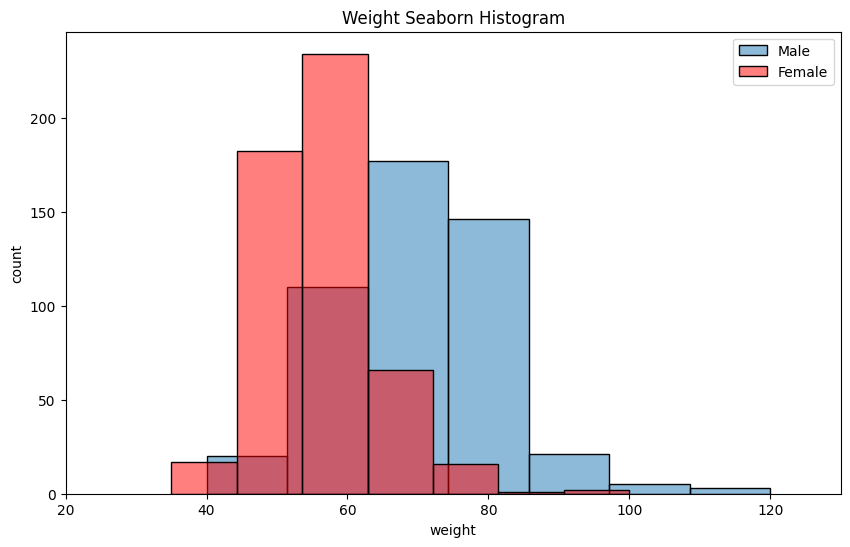

In [28]:
plt.figure(figsize=(10, 6))

sns.histplot(male_data['weight'], bins=7, alpha=0.5, label='Male')
sns.histplot(female_data['weight'], bins=7, alpha=0.5, label='Female', color='r')

plt.xlim(20,130)
plt.xlabel('weight')
plt.ylabel('count')
plt.title('Weight Seaborn Histogram')
plt.legend()
plt.show()

# 7. [시본] 음주 여부,뭄모게 상자수염 그래프

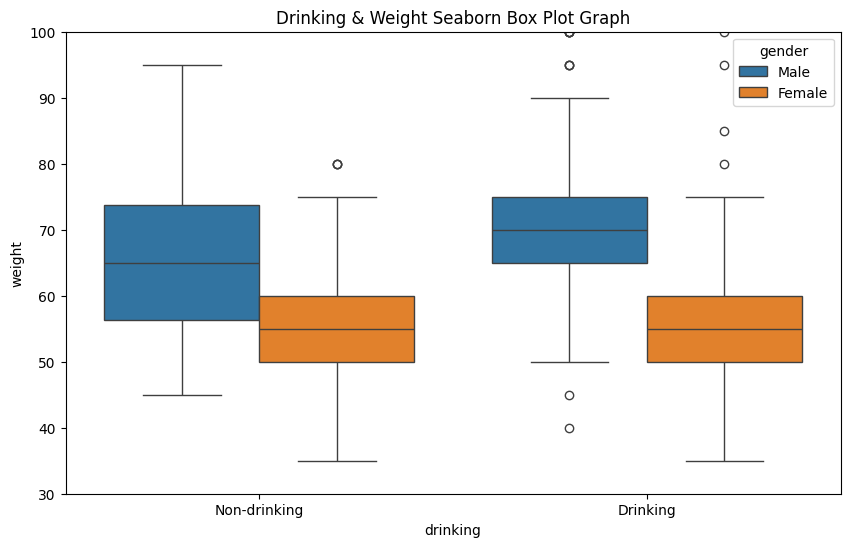

In [29]:
plt.figure(figsize=(10,6))
plt.title('Drinking & Weight Seaborn Box Plot Graph')

sns.boxplot(data=data6, x='drinking', y='weight', hue='gender')

plt.ylim(30, 100)
plt.show()

# 8.[시본] 성별 음주 여부 카운트 플롯 그래프

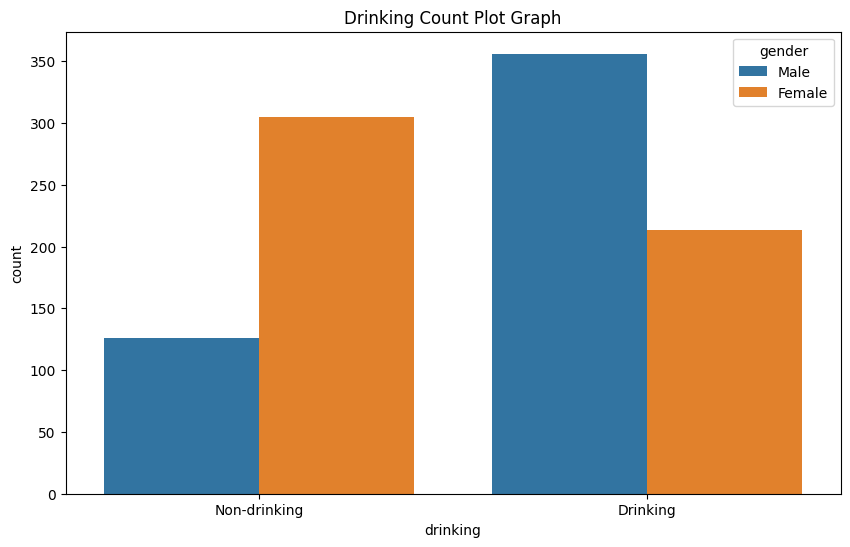

In [30]:
plt.figure(figsize=(10,6))
plt.title('Drinking Count Plot Graph')

sns.countplot(data=data6, x='drinking', hue='gender')

plt.show()

# 9. [시본] 성별, 음주 여부별 몸무게 바이올린 플롯 그래프

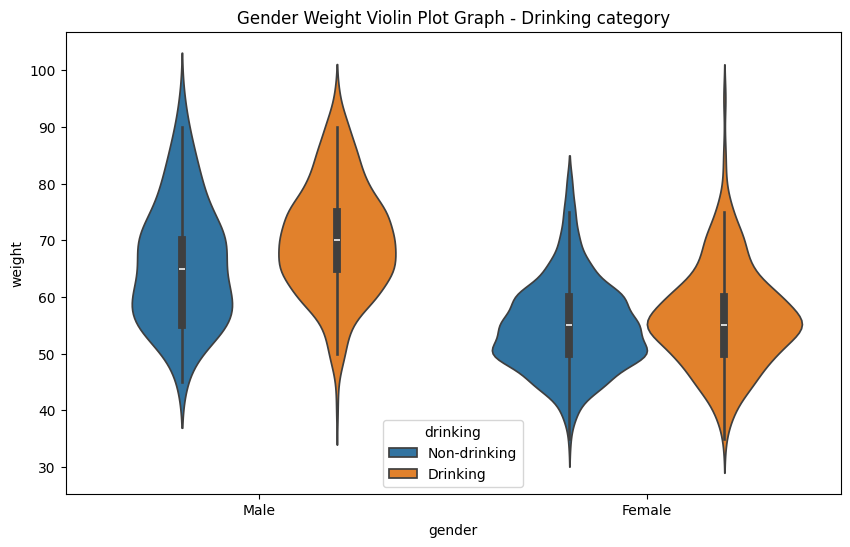

In [31]:
plt.figure(figsize=(10, 6))
plt.title('Gender Weight Violin Plot Graph - Drinking category')

sns.violinplot(data=data6[data6.weight<100], x='gender', y='weight', hue='drinking')

plt.show()

# 10. [시본] 몸무게, 허리둘레, 성별 상관관계 히트맵 그래프

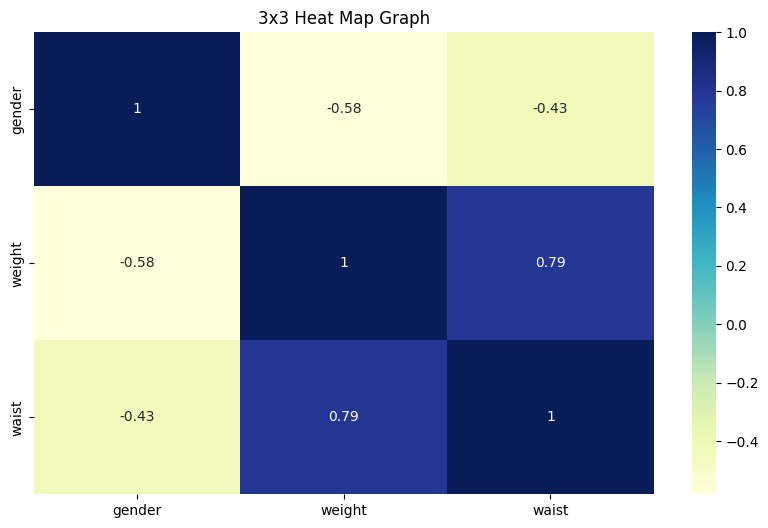

In [34]:
data3 =data.loc[:, ['gender','weight','waist']]

plt.figure(figsize=(10,6))
plt.title('3x3 Heat Map Graph')

correlation_data3 = data3.corr()
sns.heatmap(correlation_data3, annot=True, cmap='YlGnBu')

plt.show()